In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=0, dilation=dilation)

    def forward(self, x):
        x = F.pad(x, (self.padding, 0))
        return self.conv(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        self.conv1 = CausalConv1d(channels, channels, kernel_size, dilation)
        self.norm1 = nn.GroupNorm(1, channels)
        self.conv2 = CausalConv1d(channels, channels, kernel_size, dilation)
        self.norm2 = nn.GroupNorm(1, channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        residual = x
        out = self.relu(self.norm1(self.conv1(x)))
        out = self.dropout(self.norm2(self.conv2(out)))
        out += residual
        return self.relu(out)


class ResidualCausalTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_conv = nn.Conv1d(3, 32, kernel_size=1)

        dilations = [1,2,4,8,16,32,64,128]

        self.blocks = nn.Sequential(
            *[ResidualBlock(32, 5, d) for d in dilations]
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = self.input_conv(x)
        x = self.blocks(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

In [2]:
device_cpu = torch.device("cpu")

model = ResidualCausalTCN()

checkpoint = torch.load("res_models/backbone_models/checkpoint_epoch9.pth", map_location=device_cpu)
model.load_state_dict(checkpoint["model_state_dict"])

model.to(device_cpu)
model.eval()

print("Model successfully loaded on CPU.")

Model successfully loaded on CPU.


In [3]:
import time

dummy = torch.randn(1, 3, 3000)

# Warm-up
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy)

# Measure
num_runs = 300

start = time.time()
with torch.no_grad():
    for _ in range(num_runs):
        _ = model(dummy)
end = time.time()

avg_time_ms = (end - start) / num_runs * 1000
print("Average inference time:", avg_time_ms, "ms")

Average inference time: 13.154947757720947 ms


In [5]:
import torch
import numpy as np
import seisbench.data as sbd
from torch.utils.data import Dataset, DataLoader

# Load dataset
dataset = sbd.STEAD()

label_map = {"noise": 0, "earthquake_local": 1}
dataset.metadata["label"] = dataset.metadata["trace_category"].map(label_map)

dev_indices = dataset.metadata[dataset.metadata["split"] == "dev"].index


class SteadTorchDataset(Dataset):
    def __init__(self, dataset, indices, crop_len=3000):
        self.dataset = dataset
        self.indices = indices
        self.crop_len = crop_len

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        wf = self.dataset.get_waveforms([real_idx])[0]

        # Same crop as training
        wf = wf[:, :self.crop_len]

        # Same normalization
        wf = wf - wf.mean(axis=1, keepdims=True)
        wf = wf / (wf.std(axis=1, keepdims=True) + 1e-6)

        label = self.dataset.metadata.iloc[real_idx]["label"]

        return torch.tensor(wf, dtype=torch.float32), \
               torch.tensor(label, dtype=torch.float32)


dev_dataset = SteadTorchDataset(dataset, dev_indices)
dev_loader = DataLoader(dev_dataset,
                        batch_size=32,
                        shuffle=False,
                        num_workers=2)

print("Validation loader ready.")

/home/namithk/miniconda3/envs/eew/lib/python3.9/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-03-03 11:13:10,335 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


Validation loader ready.


In [9]:
device = torch.device("cuda")

model.to(device)
model.eval()

ResidualCausalTCN(
  (input_conv): Conv1d(3, 32, kernel_size=(1,), stride=(1,))
  (blocks): Sequential(
    (0): ResidualBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,))
      )
      (norm1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,))
      )
      (norm2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (relu): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): ResidualBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,), dilation=(2,))
      )
      (norm1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,), dilation=(2,))
      )
      (norm2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (relu): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): ResidualBlock(
      (conv1): CausalConv1

In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in dev_loader:
        x = x.to(device)
        outputs = model(x)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs.extend(probs.flatten())
        all_labels.extend(y.numpy().flatten())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [11]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for t in thresholds:
    preds = (all_probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    fpr = fp / (fp + tn + 1e-8)

    results.append((t, precision, recall, fpr))

for r in results:
    print(f"Threshold: {r[0]:.2f} | Precision: {r[1]:.4f} | Recall: {r[2]:.4f} | FPR: {r[3]:.6f}")

Threshold: 0.10 | Precision: 0.9998 | Recall: 0.9883 | FPR: 0.000764
Threshold: 0.15 | Precision: 0.9998 | Recall: 0.9882 | FPR: 0.000680
Threshold: 0.20 | Precision: 0.9998 | Recall: 0.9880 | FPR: 0.000680
Threshold: 0.25 | Precision: 0.9998 | Recall: 0.9880 | FPR: 0.000680
Threshold: 0.30 | Precision: 0.9998 | Recall: 0.9879 | FPR: 0.000680
Threshold: 0.35 | Precision: 0.9998 | Recall: 0.9879 | FPR: 0.000680
Threshold: 0.40 | Precision: 0.9998 | Recall: 0.9878 | FPR: 0.000680
Threshold: 0.45 | Precision: 0.9998 | Recall: 0.9877 | FPR: 0.000680
Threshold: 0.50 | Precision: 0.9998 | Recall: 0.9877 | FPR: 0.000680
Threshold: 0.55 | Precision: 0.9998 | Recall: 0.9875 | FPR: 0.000680
Threshold: 0.60 | Precision: 0.9998 | Recall: 0.9875 | FPR: 0.000680
Threshold: 0.65 | Precision: 0.9998 | Recall: 0.9874 | FPR: 0.000680
Threshold: 0.70 | Precision: 0.9998 | Recall: 0.9873 | FPR: 0.000680
Threshold: 0.75 | Precision: 0.9998 | Recall: 0.9872 | FPR: 0.000680
Threshold: 0.80 | Precision: 0.999

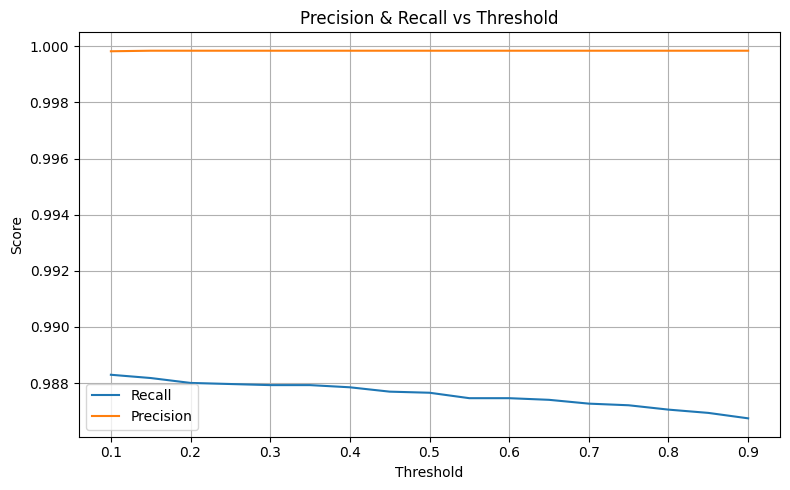

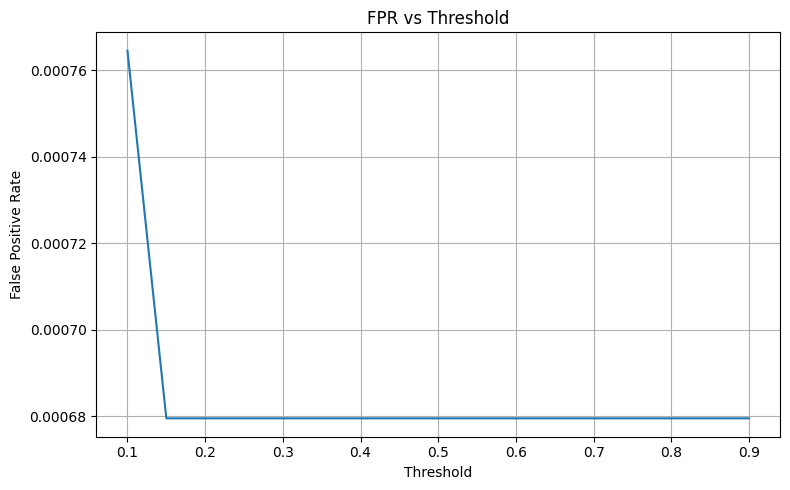

In [12]:
import matplotlib.pyplot as plt

thresholds = [r[0] for r in results]
precisions = [r[1] for r in results]
recalls = [r[2] for r in results]
fprs = [r[3] for r in results]

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(thresholds, fprs)
plt.xlabel("Threshold")
plt.ylabel("False Positive Rate")
plt.title("FPR vs Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()